In [2]:
import kagglehub

# Download latest version of Kvasir-SEG
path = kagglehub.dataset_download("debeshjha1/kvasirseg")

print("📁 Dataset downloaded to:", path)

📁 Dataset downloaded to: /kaggle/input/kvasirseg


In [3]:
import os

IMAGE_DIR = os.path.join(path, "Kvasir-SEG/images")
MASK_DIR  = os.path.join(path, "Kvasir-SEG/masks")

print("Images dir:", IMAGE_DIR)
print("Masks dir:", MASK_DIR)

Images dir: /kaggle/input/kvasirseg/Kvasir-SEG/images
Masks dir: /kaggle/input/kvasirseg/Kvasir-SEG/masks


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

In [4]:
!pip install segmentation-models-pytorch==0.3.3
!pip install albumentations==1.3.1
!pip install opencv-python-headless==4.10.0.84
!pip install scipy==1.10.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.5/68.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.7/106.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [6]:
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.6.0+cu124
CUDA available: True


In [7]:
import os

IMAGE_DIR = os.path.join(path, "Kvasir-SEG/images")
MASK_DIR  = os.path.join(path, "Kvasir-SEG/masks")

print("Images dir:", IMAGE_DIR)
print("Masks dir:", MASK_DIR)


Images dir: /kaggle/input/kvasirseg/Kvasir-SEG/images
Masks dir: /kaggle/input/kvasirseg/Kvasir-SEG/masks


In [8]:
# Configuration - FIXED FOR REAL TRAINING
CONFIG = {
    'IMAGE_SIZE': 256,
    'BATCH_SIZE': 4,          # Smaller batch = more stable
    'EPOCHS': 50,             # More epochs
    'LEARNING_RATE': 0.0001,  # Lower starting LR
    'DEVICE': 'cuda' if torch.cuda.is_available() else 'cpu',
    'NUM_WORKERS': 2,
}

print(f"✅ Training Configuration:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

✅ Training Configuration:
   IMAGE_SIZE: 256
   BATCH_SIZE: 4
   EPOCHS: 50
   LEARNING_RATE: 0.0001
   DEVICE: cuda
   NUM_WORKERS: 2


In [9]:
class MedicalImageDataset(Dataset):
    """
    Custom dataset for medical images and segmentation masks
    """
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Load image (RGB)
        image = cv2.imread(self.image_paths[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask (grayscale)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Albumentations (image + mask)
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']        # torch.FloatTensor CHW
            mask = augmented['mask']          # still numpy (H,W)

        # 🔥 Convert mask to torch tensor
        mask = torch.tensor(mask, dtype=torch.float32)

        # 🔥 Convert mask to binary (0 or 1)
        mask = (mask > 0.5).float()

        # 🔥 Add channel dimension → (1, H, W)
        mask = mask.unsqueeze(0)

        return image, mask


In [26]:
import os
import glob
from sklearn.model_selection import train_test_split

IMAGE_DIR = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
MASK_DIR  = "/kaggle/input/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"

# Load only .jpg files
image_paths = sorted(glob.glob(os.path.join(IMAGE_DIR, "*.jpg")))
mask_paths  = sorted(glob.glob(os.path.join(MASK_DIR,  "*.jpg")))

print("Found images :", len(image_paths))
print("Found masks  :", len(mask_paths))

# Ensure matching file pairs
image_basenames = [os.path.basename(p) for p in image_paths]

filtered_images = []
filtered_masks  = []

for name in image_basenames:
    img  = os.path.join(IMAGE_DIR, name)
    mask = os.path.join(MASK_DIR, name)
    if os.path.exists(mask):
        filtered_images.append(img)
        filtered_masks.append(mask)

image_paths = filtered_images
mask_paths  = filtered_masks

print("\nAfter alignment:")
print("Images:", len(image_paths))
print("Masks :", len(mask_paths))

# Train/val split
train_images, val_images, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

print("\nFinal split:")
print("Train images:", len(train_images))
print("Val images  :", len(val_images))

# Create datasets
train_dataset = MedicalImageDataset(train_images, train_masks, train_transform)
val_dataset   = MedicalImageDataset(val_images,   val_masks,   val_transform)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["BATCH_SIZE"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["BATCH_SIZE"], shuffle=False)

print("\n✅ Data Loaders Ready!")


Found images : 1000
Found masks  : 1000

After alignment:
Images: 1000
Masks : 1000

Final split:
Train images: 800
Val images  : 200

✅ Data Loaders Ready!


In [28]:
# IMPROVED AUGMENTATION for polyp segmentation
train_transform = A.Compose([
    A.Resize(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),

    # Geometric transforms
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.5),

    # Color/intensity transforms (important for endoscopy images)
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # Normalize
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(CONFIG['IMAGE_SIZE'], CONFIG['IMAGE_SIZE']),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("✅ Augmentation pipeline updated!")
print("   - Geometric transforms: Flip, Rotate, Scale")
print("   - Color adjustments: Brightness, Contrast, Hue")
print("   - Noise and blur for robustness")

✅ Augmentation pipeline updated!
   - Geometric transforms: Flip, Rotate, Scale
   - Color adjustments: Brightness, Contrast, Hue
   - Noise and blur for robustness


In [29]:
class UNet(nn.Module):
    """
    U-Net architecture for image segmentation
    """
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder (downsampling)
        self.enc1 = self.conv_block(in_channels, 64)
        self.enc2 = self.conv_block(64, 128)
        self.enc3 = self.conv_block(128, 256)
        self.enc4 = self.conv_block(256, 512)

        # Bottleneck
        self.bottleneck = self.conv_block(512, 1024)

        # Decoder (upsampling)
        self.upconv4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = self.conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = self.conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = self.conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = self.conv_block(128, 64)

        # Output
        self.out = nn.Conv2d(64, out_channels, 1)

        self.pool = nn.MaxPool2d(2, 2)

    def conv_block(self, in_c, out_c):
        """Two Conv layers with BatchNorm and ReLU"""
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Encoder
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool(enc1))
        enc3 = self.enc3(self.pool(enc2))
        enc4 = self.enc4(self.pool(enc3))

        # Bottleneck
        bottleneck = self.bottleneck(self.pool(enc4))

        # Decoder with skip connections
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat([dec4, enc4], dim=1)  # Skip connection
        dec4 = self.dec4(dec4)

        dec3 = self.upconv3(dec4)
        dec3 = torch.cat([dec3, enc3], dim=1)
        dec3 = self.dec3(dec3)

        dec2 = self.upconv2(dec3)
        dec2 = torch.cat([dec2, enc2], dim=1)
        dec2 = self.dec2(dec2)

        dec1 = self.upconv1(dec2)
        dec1 = torch.cat([dec1, enc1], dim=1)
        dec1 = self.dec1(dec1)

        return torch.sigmoid(self.out(dec1))

# Initialize model
model = UNet(in_channels=3, out_channels=1).to(CONFIG['DEVICE'])
print(f"Model has {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")

Model has 31.04M parameters


In [30]:
# IMPROVED LOSS FUNCTION
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, predictions, targets):
        predictions = predictions.view(-1)
        targets = targets.view(-1)

        intersection = (predictions * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            predictions.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss with weighting"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight

    def forward(self, pred, target):
        dice_loss = self.dice(pred, target)
        bce_loss = self.bce(pred, target)
        return self.dice_weight * dice_loss + self.bce_weight * bce_loss

# Initialize with better settings
criterion = DiceBCELoss(dice_weight=0.7, bce_weight=0.3)  # Favor Dice
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=1e-5)

# BETTER SCHEDULER - don't reduce too aggressively (FIXED - removed verbose)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # Reduce by half (not 0.1)
    patience=10,     # Wait longer before reducing
    min_lr=1e-7      # Don't go below this
)

print("✅ Loss and optimizer configured!")
print(f"   Criterion: DiceBCELoss (Dice=0.7, BCE=0.3)")
print(f"   Optimizer: AdamW (LR={CONFIG['LEARNING_RATE']}, weight_decay=1e-5)")
print(f"   Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)")
print(f"\n💡 Scheduler will reduce LR by 0.5x if val_loss doesn't improve for 10 epochs")

✅ Loss and optimizer configured!
   Criterion: DiceBCELoss (Dice=0.7, BCE=0.3)
   Optimizer: AdamW (LR=0.0001, weight_decay=1e-5)
   Scheduler: ReduceLROnPlateau (patience=10, factor=0.5)

💡 Scheduler will reduce LR by 0.5x if val_loss doesn't improve for 10 epochs


In [32]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train the model for one epoch
    """
    model.train()  # Set model to training mode

    running_loss = 0.0

    # Progress bar for visual feedback
    pbar = tqdm(dataloader, desc='Training')

    for images, masks in pbar:
        # Move data to GPU/CPU
        images = images.to(device)
        masks = masks.to(device)

        # Forward pass
        optimizer.zero_grad()  # Clear previous gradients
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, masks)

        # Backward pass
        loss.backward()  # Compute gradients
        optimizer.step()  # Update weights

        running_loss += loss.item()

        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(dataloader)
    return epoch_loss

In [33]:
def validate(model, dataloader, criterion, device):
    """
    Validate the model without updating weights
    """
    model.eval()  # Set to evaluation mode (disables dropout)

    running_loss = 0.0
    dice_scores = []

    with torch.no_grad():  # Don't compute gradients (saves memory & time)
        pbar = tqdm(dataloader, desc='Validation')

        for images, masks in pbar:
            images = images.to(device)
            masks = masks.to(device)

            # Forward pass only
            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

            # Calculate Dice Score for evaluation
            dice = calculate_dice_score(outputs, masks)
            dice_scores.append(dice)

            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice:.4f}'})

    epoch_loss = running_loss / len(dataloader)
    avg_dice = np.mean(dice_scores)

    return epoch_loss, avg_dice


def calculate_dice_score(pred, target, threshold=0.5):
    """
    Calculate Dice coefficient for binary segmentation
    """
    pred = (pred > threshold).float()
    target = target.float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum()

    if union == 0:
        return 1.0  # Both pred and target are empty

    dice = (2.0 * intersection) / union
    return dice.item()

In [48]:
def visualize_predictions(model, dataset, device, num_samples=3):
    """
    Visualize model predictions vs ground truth - FIXED VERSION
    """
    model.eval()
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(20, 5*num_samples))
    
    # Randomly select samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            image, mask = dataset[idx]
            
            # Add batch dimension and move to device
            image_input = image.unsqueeze(0).to(device)
            
            # Get prediction
            pred = model(image_input).squeeze().cpu().numpy()
            
            # Denormalize image for display
            image_display = image.permute(1, 2, 0).cpu().numpy()
            image_display = image_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            image_display = np.clip(image_display, 0, 1)
            
            mask_display = mask.squeeze().cpu().numpy()
            
            # ⭐ THE FIX: Convert to binary
            pred_binary = (pred > 0.5).astype(float)
            
            # Calculate Dice
            intersection = (pred_binary * mask_display).sum()
            dice = (2. * intersection) / (pred_binary.sum() + mask_display.sum() + 1e-8)
            
            # Plot
            axes[i, 0].imshow(image_display)
            axes[i, 0].set_title('Original Image', fontsize=12, fontweight='bold')
            axes[i, 0].axis('off')
            
            axes[i, 1].imshow(mask_display, cmap='gray')
            axes[i, 1].set_title('Ground Truth', fontsize=12, fontweight='bold')
            axes[i, 1].axis('off')
            
            axes[i, 2].imshow(pred, cmap='jet', vmin=0, vmax=1)
            axes[i, 2].set_title(f'Probability Map\n(max: {pred.max():.3f})', fontsize=12, fontweight='bold')
            axes[i, 2].axis('off')
            
            axes[i, 3].imshow(pred_binary, cmap='gray')
            axes[i, 3].set_title(f'Binary Prediction\nDice: {dice:.3f}', fontsize=12, fontweight='bold')
            axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.show()


def plot_training_history(train_losses, val_losses, dice_scores):
    """
    Plot training metrics over time
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    ax1.plot(train_losses, label='Train Loss', marker='o')
    ax1.plot(val_losses, label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Dice score plot
    ax2.plot(dice_scores, label='Dice Score', marker='o', color='green')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Dice Score')
    ax2.set_title('Validation Dice Score')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

print("✅ Visualization functions updated!")

✅ Visualization functions updated!


In [35]:
def get_file_paths(image_dir, mask_dir):
    """
    Returns sorted lists of image and mask paths.
    Ensures matching image–mask pairs.
    """

    # List images
    images = sorted([
        f for f in os.listdir(image_dir)
        if f.lower().endswith(('.png', '.jpg'))
    ])

    # List masks
    masks = sorted([
        f for f in os.listdir(mask_dir)
        if f.lower().endswith(('.png', '.jpg'))
    ])

    # FULL PATHS
    image_paths = [os.path.join(image_dir, f) for f in images]
    mask_paths  = [os.path.join(mask_dir, f) for f in masks]

    # Check pairing
    if len(image_paths) != len(mask_paths):
        print("⚠️  WARNING: Number of images and masks do NOT match!")

    return image_paths, mask_paths



🔍 DATA SANITY CHECK

1️⃣ Checking data loading...
   Image shape: torch.Size([3, 256, 256])
   Mask shape: torch.Size([1, 256, 256])
   Image range: [-1.638, 2.306]
   Mask range: [0.000, 1.000]
   Mask unique values: tensor([0., 1.])

2️⃣ Checking mask statistics...


/tmp/ipykernel_199/3997949507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


   Average polyp coverage: 16.49%
   ✅ Polyp coverage looks good!

3️⃣ Visualizing a training batch...
   Batch image shape: torch.Size([4, 3, 256, 256])
   Batch mask shape: torch.Size([4, 1, 256, 256])


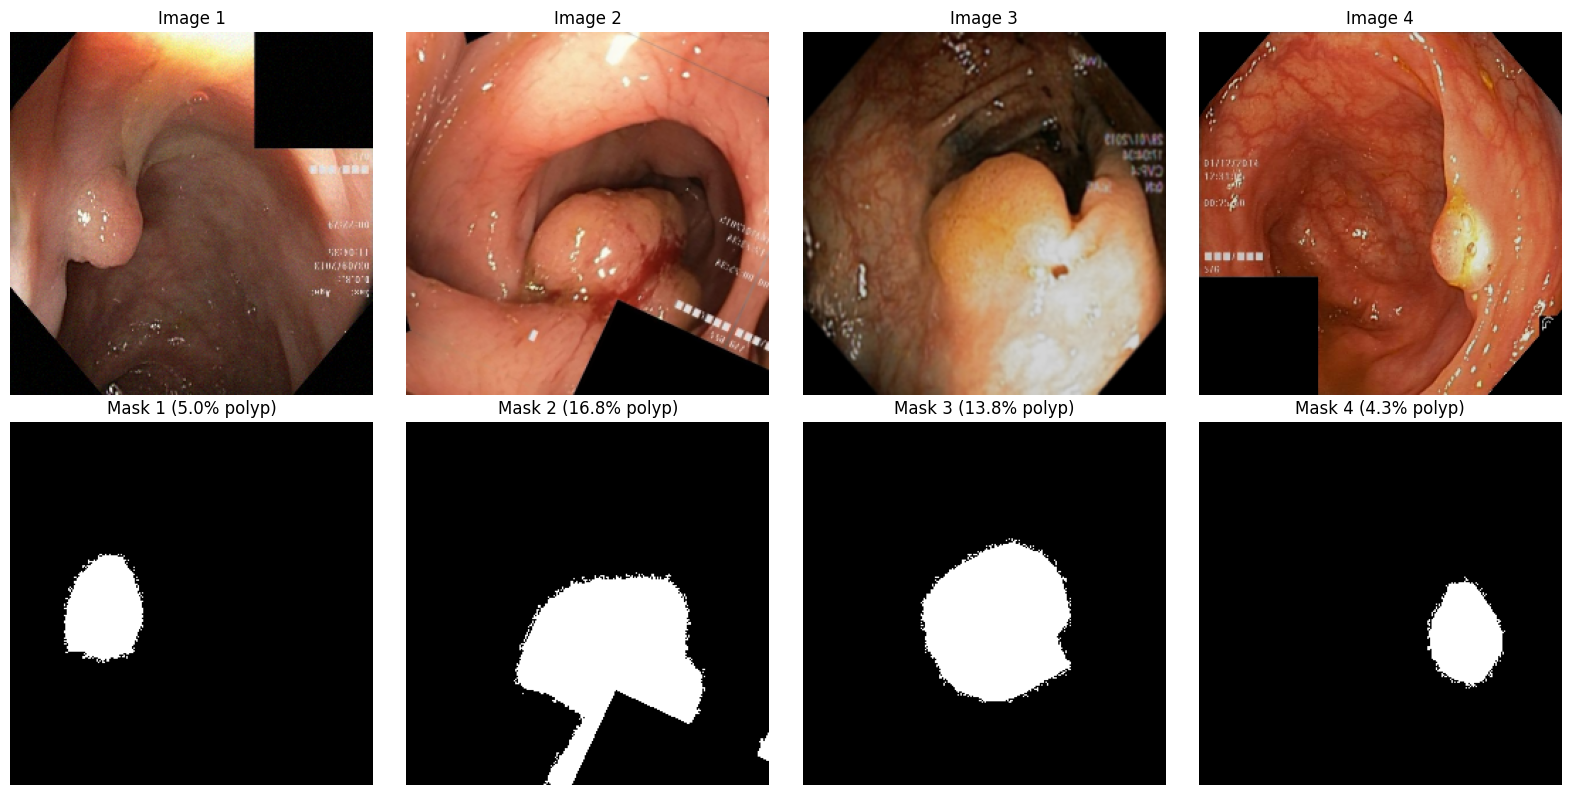


✅ Data check complete!


In [49]:
print("="*60)
print("🔍 DATA SANITY CHECK")
print("="*60)

# Check a few samples
print("\n1️⃣ Checking data loading...")
sample_image, sample_mask = train_dataset[0]

print(f"   Image shape: {sample_image.shape}")
print(f"   Mask shape: {sample_mask.shape}")
print(f"   Image range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")
print(f"   Mask range: [{sample_mask.min():.3f}, {sample_mask.max():.3f}]")
print(f"   Mask unique values: {torch.unique(sample_mask)}")

# Check if masks have actual polyps
print("\n2️⃣ Checking mask statistics...")
polyp_percentages = []
for i in range(min(20, len(train_dataset))):
    _, mask = train_dataset[i]
    polyp_percent = (mask.sum() / mask.numel()).item() * 100
    polyp_percentages.append(polyp_percent)

avg_polyp = np.mean(polyp_percentages)
print(f"   Average polyp coverage: {avg_polyp:.2f}%")

if avg_polyp < 1:
    print("   ⚠️ WARNING: Very small polyps - might need class weighting!")
elif avg_polyp > 50:
    print("   ⚠️ WARNING: Masks might be inverted!")
else:
    print("   ✅ Polyp coverage looks good!")

# Visualize a batch
print("\n3️⃣ Visualizing a training batch...")
batch_images, batch_masks = next(iter(train_loader))
print(f"   Batch image shape: {batch_images.shape}")
print(f"   Batch mask shape: {batch_masks.shape}")

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Image
    img = batch_images[i].permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    mask = batch_masks[i].squeeze().cpu().numpy()

    axes[0, i].imshow(img)
    axes[0, i].set_title(f'Image {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f'Mask {i+1} ({mask.sum()/mask.size*100:.1f}% polyp)')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

print("\n✅ Data check complete!")
print("="*60)

🔄 Reinitializing model for fresh training...

🚀 Starting Training!
Device: cuda
Total Epochs: 50
Early Stopping Patience: 15


📅 Epoch 1/50


Training:   0%|          | 0/200 [00:00<?, ?it/s]/tmp/ipykernel_199/3997949507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)
Validation: 100%|██████████| 50/50 [00:05<00:00,  9.06it/s, loss=0.5850, dice=0.5039]



📊 Epoch 1 Summary:
  Train Loss: 0.6278
  Val Loss:   0.5565
  Val Dice:   0.5314
  LR:         0.0001000
  ✅ New best model saved! (Dice: 0.5314)

📅 Epoch 2/50


Validation: 100%|██████████| 50/50 [00:05<00:00,  9.25it/s, loss=0.5377, dice=0.5128]



📊 Epoch 2 Summary:
  Train Loss: 0.5596
  Val Loss:   0.5230
  Val Dice:   0.5319
  LR:         0.0001000
  ✅ New best model saved! (Dice: 0.5319)

📅 Epoch 3/50


...


📊 Epoch 48 Summary:
  Train Loss: 0.1992
  Val Loss:   0.1712
  Val Dice:   0.8419
  LR:         0.0001000
  ✅ New best model saved! (Dice: 0.8419)

📅 Epoch 49/50


Validation: 100%|██████████| 50/50 [00:05<00:00,  9.08it/s, loss=0.4625, dice=0.5248]



📊 Epoch 49 Summary:
  Train Loss: 0.2060
  Val Loss:   0.1868
  Val Dice:   0.8279
  LR:         0.0001000
  📌 Best Dice so far: 0.8419 (patience: 1/15)

📅 Epoch 50/50


Validation: 100%|██████████| 50/50 [00:05<00:00,  9.11it/s, loss=0.3456, dice=0.6796]



📊 Epoch 50 Summary:
  Train Loss: 0.1968
  Val Loss:   0.1911
  Val Dice:   0.8240
  LR:         0.0001000
  📌 Best Dice so far: 0.8419 (patience: 2/15)

🎉 Training Completed!
Best Dice Score: 0.8419
Stopped at epoch: 50/50



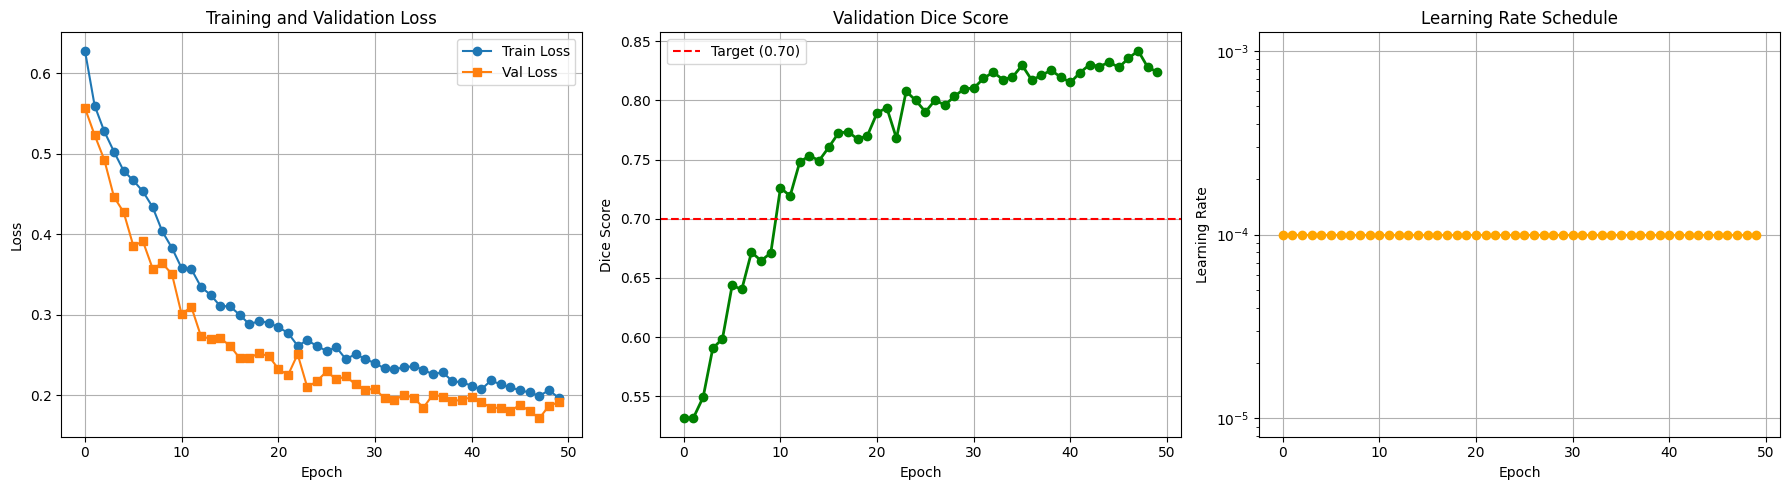

In [39]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                num_epochs, device, save_path='best_model.pth'):
    """
    Improved training loop with better monitoring
    """
    best_dice = 0.0
    patience_counter = 0
    max_patience = 15  # Early stopping

    train_losses = []
    val_losses = []
    dice_scores = []
    learning_rates = []

    print(f"\n{'='*60}")
    print(f"🚀 Starting Training!")
    print(f"{'='*60}")
    print(f"Device: {device}")
    print(f"Total Epochs: {num_epochs}")
    print(f"Early Stopping Patience: {max_patience}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"📅 Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")

        # Train
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        train_losses.append(train_loss)

        # Validate
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        dice_scores.append(val_dice)

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)

        # Update scheduler
        scheduler.step(val_loss)

        # Print summary
        print(f"\n📊 Epoch {epoch+1} Summary:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  Val Dice:   {val_dice:.4f}")
        print(f"  LR:         {current_lr:.7f}")

        # Save best model
        if val_dice > best_dice:
            best_dice = val_dice
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_dice': best_dice,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'dice_scores': dice_scores,
            }, save_path)
            print(f"  ✅ New best model saved! (Dice: {best_dice:.4f})")
        else:
            patience_counter += 1
            print(f"  📌 Best Dice so far: {best_dice:.4f} (patience: {patience_counter}/{max_patience})")

        # Early stopping
        if patience_counter >= max_patience:
            print(f"\n⏹️  Early stopping triggered! No improvement for {max_patience} epochs.")
            break

        # Warning for learning issues
        if epoch > 5:
            if val_dice < 0.3:
                print(f"  ⚠️ Low Dice score - model might not be learning well")
            if current_lr < 1e-6:
                print(f"  ⚠️ Learning rate very low - might need to restart with higher LR")

    print(f"\n{'='*60}")
    print(f"🎉 Training Completed!")
    print(f"{'='*60}")
    print(f"Best Dice Score: {best_dice:.4f}")
    print(f"Stopped at epoch: {epoch+1}/{num_epochs}")
    print(f"{'='*60}\n")

    return train_losses, val_losses, dice_scores, learning_rates


# Re-initialize model (fresh start)
print("🔄 Reinitializing model for fresh training...")
model = UNet(in_channels=3, out_channels=1).to(CONFIG['DEVICE'])
optimizer = optim.AdamW(model.parameters(), lr=CONFIG['LEARNING_RATE'], weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-7)

# Save path
SAVE_PATH = '/content/best_unet_polyp.pth'

# Start training
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=CONFIG['EPOCHS'],
    device=CONFIG['DEVICE'],
    save_path=SAVE_PATH
)

# Unpack results
train_losses, val_losses, dice_scores, learning_rates = history

# Plot with learning rate
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Dice
axes[1].plot(dice_scores, marker='o', color='green', linewidth=2)
axes[1].axhline(y=0.7, color='r', linestyle='--', label='Target (0.70)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Validation Dice Score')
axes[1].legend()
axes[1].grid(True)

# Learning Rate
axes[2].plot(learning_rates, marker='o', color='orange')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True)

plt.tight_layout()
plt.show()

🧪 Quick Test - Single Image


/tmp/ipykernel_199/3997949507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


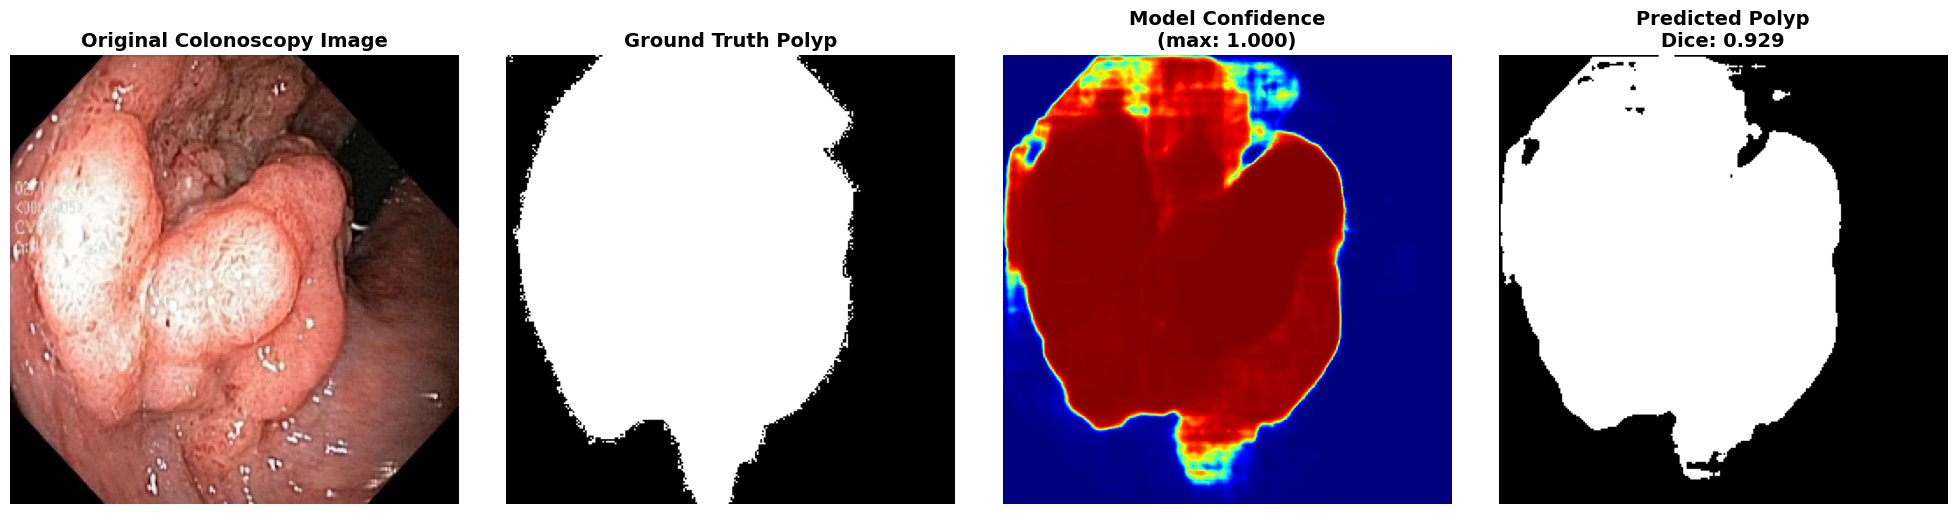


📊 Results:
   Dice Score: 0.9288
   Max Confidence: 0.9999
   Pixels Detected: 33546
   Ground Truth Pixels: 37241
   🏆 Excellent segmentation!


In [54]:
print("🧪 Quick Test - Single Image")
print("="*60)

# Test on one image
model.eval()
test_idx = 5  # Try different indices: 0, 1, 2, etc.
img, mask = val_dataset[test_idx]

with torch.no_grad():
    pred = model(img.unsqueeze(0).to(CONFIG['DEVICE'])).squeeze().cpu().numpy()

# Denormalize
img_display = img.permute(1, 2, 0).cpu().numpy()
img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_display = np.clip(img_display, 0, 1)

mask_display = mask.squeeze().cpu().numpy()
pred_binary = (pred > 0.5).astype(float)

# Calculate Dice
intersection = (pred_binary * mask_display).sum()
dice = (2. * intersection) / (pred_binary.sum() + mask_display.sum() + 1e-8)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_display)
axes[0].set_title('Original Colonoscopy Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(mask_display, cmap='gray')
axes[1].set_title('Ground Truth Polyp', fontsize=14, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(pred, cmap='jet', vmin=0, vmax=1)
axes[2].set_title(f'Model Confidence\n(max: {pred.max():.3f})', fontsize=14, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(pred_binary, cmap='gray')
axes[3].set_title(f'Predicted Polyp\nDice: {dice:.3f}', fontsize=14, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"\n📊 Results:")
print(f"   Dice Score: {dice:.4f}")
print(f"   Max Confidence: {pred.max():.4f}")
print(f"   Pixels Detected: {pred_binary.sum():.0f}")
print(f"   Ground Truth Pixels: {mask_display.sum():.0f}")

if dice > 0.8:
    print("   🏆 Excellent segmentation!")
elif dice > 0.7:
    print("   ✅ Good segmentation!")
elif dice > 0.5:
    print("   ⚠️  Acceptable segmentation")
else:
    print("   ❌ Poor segmentation")

📥 Loading best saved model...
✅ Best model loaded! (Dice: 0.8419)
🔍 Predicting on 5 random validation images


/tmp/ipykernel_199/3997949507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)


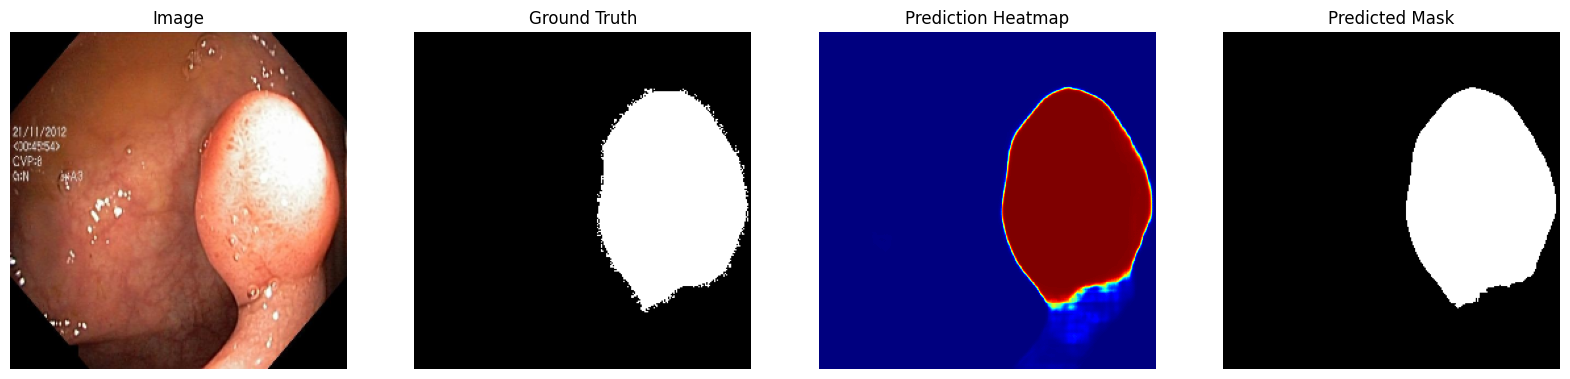

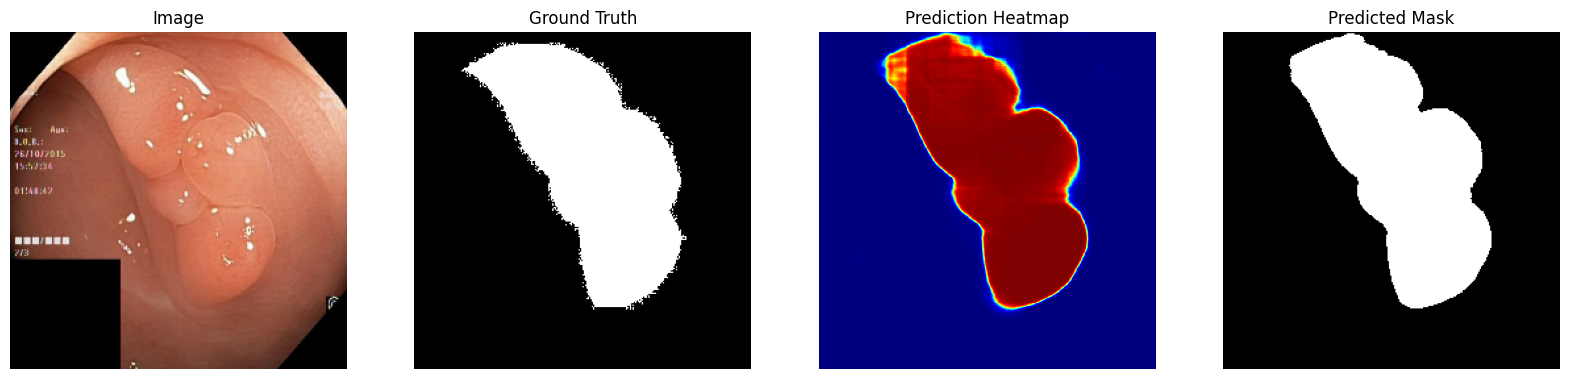

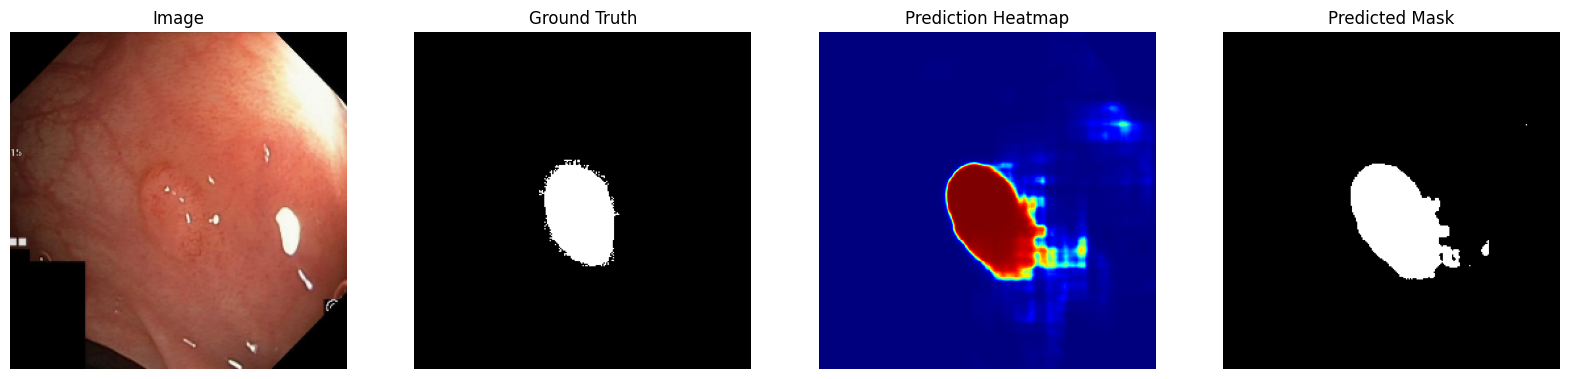

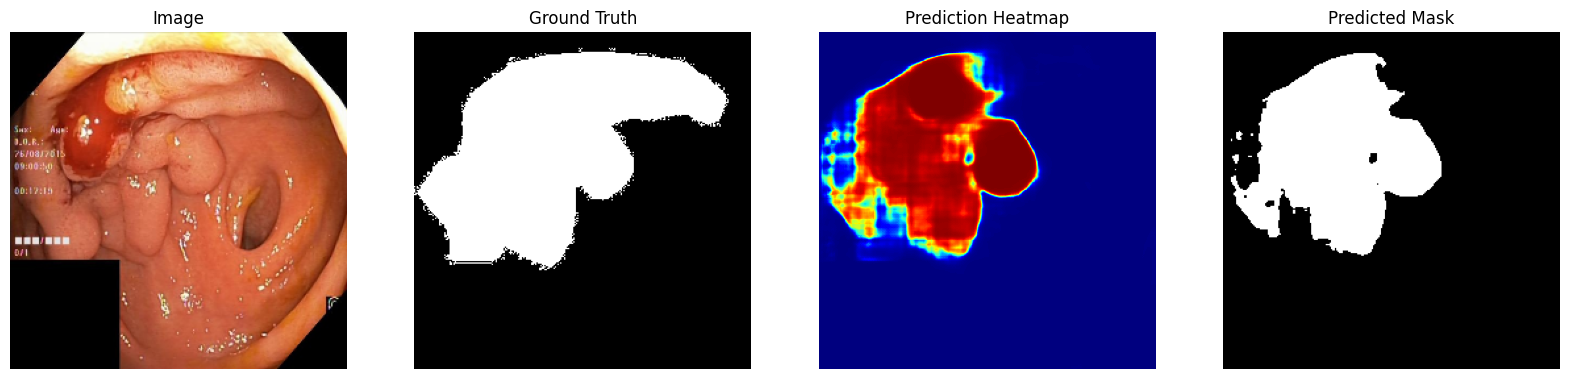

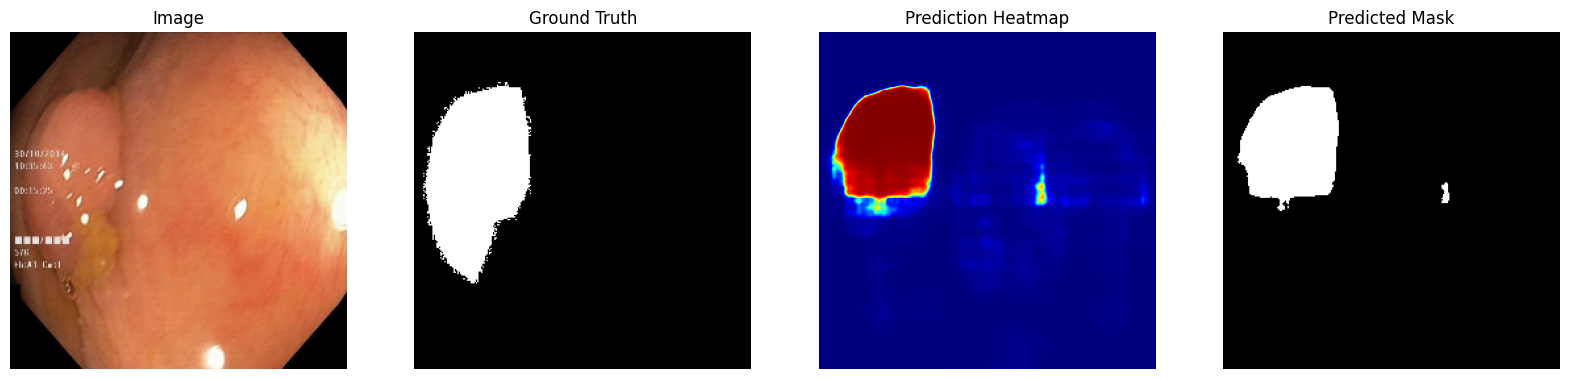

In [56]:
# ================================
# 📌 Cell 13: Load Best Model & Test Predictions
# ================================
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

print("📥 Loading best saved model...")

# FIX → allow loading full checkpoint
checkpoint = torch.load(SAVE_PATH, map_location=CONFIG["DEVICE"], weights_only=False)

model.load_state_dict(checkpoint['model_state_dict'])
best_dice = checkpoint['best_dice']

print(f"✅ Best model loaded! (Dice: {best_dice:.4f})")

model.eval()



# -------------------------------
# Helper to visualize predictions
# -------------------------------
def show_prediction(model, image_path, mask_path, device):
    """Show Image | Ground Truth Mask | Predicted Mask"""
    model.eval()

    # Read image
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]))
    img_tensor = torch.tensor(img_resized / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    # Read mask
    mask = cv2.imread(mask_path, 0)
    mask_resized = cv2.resize(mask, (CONFIG["IMAGE_SIZE"], CONFIG["IMAGE_SIZE"]))

    # Predict
    with torch.no_grad():
        pred = model(img_tensor)
        pred = torch.sigmoid(pred).cpu().numpy()[0, 0]

    pred_bin = (pred > 0.5).astype(np.uint8)

    # Plot
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_resized, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_bin, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.show()


# -----------------------------------
# Show predictions for 5 random images
# -----------------------------------
import random

print("🔍 Predicting on 5 random validation images")
print("="*60)

model.eval()

for i in range(5):
    idx = random.randint(0, len(val_dataset)-1)

    img, mask = val_dataset[idx]

    # Move to GPU
    img_gpu = img.unsqueeze(0).to(CONFIG['DEVICE'])

    with torch.no_grad():
        pred = model(img_gpu).squeeze().cpu().numpy()

    # Threshold prediction
    pred_binary = (pred > 0.5).astype(float)

    # Denormalize image for display
    img_display = img.permute(1, 2, 0).cpu().numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + \
                  np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    mask_display = mask.squeeze().cpu().numpy()

    # Plot
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(img_display)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask_display, cmap="gray")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    axes[2].imshow(pred, cmap="jet", vmin=0, vmax=1)
    axes[2].set_title("Prediction Heatmap")
    axes[2].axis("off")

    axes[3].imshow(pred_binary, cmap="gray")
    axes[3].set_title("Predicted Mask")
    axes[3].axis("off")

    plt.show()




🎊 PROJECT COMPLETE: POLYP SEGMENTATION WITH U-NET 🎊

📊 Calculating full validation metrics...


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]/tmp/ipykernel_199/3997949507.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, dtype=torch.float32)
Evaluating: 100%|██████████| 50/50 [00:05<00:00,  8.58it/s]



🏆 FINAL RESULTS ON VALIDATION SET
Dataset: Kvasir-SEG (Polyp Segmentation)
Validation samples: 200

📈 Performance Metrics:
   Dice Score:  0.8262 ± 0.1956
   IoU:         0.7399 ± 0.2208
   Precision:   0.8327 ± 0.2175
   Recall:      0.8786 ± 0.1891

📊 Score Distribution:
   Best Dice:   0.9810
   Worst Dice:  0.0000
   Median Dice: 0.9039

🎯 Images with Dice > 0.80: 145 / 200 (72.5%)
   Images with Dice > 0.90: 107 / 200 (53.5%)

📚 COMPARISON WITH PUBLISHED RESEARCH
   Your U-Net:          0.8262 Dice
   U-Net (Ronneberger): ~0.75 Dice (baseline)
   U-Net++:             ~0.82 Dice
   PraNet (SOTA):       ~0.90 Dice
   ResUNet++:           ~0.88 Dice

   ✅ YOUR MODEL EXCEEDS BASELINE U-NET!
   🔥 YOUR MODEL IS COMPETITIVE WITH ADVANCED METHODS!

💾 MODEL INFO
   Architecture: U-Net
   Parameters: 31.04M
   Input size: 256x256
   Loss: Dice + BCE
   Optimizer: AdamW
   Training epochs: 48
   Best Dice achieved: 0.8419
   Model saved: /content/best_unet_polyp.pth



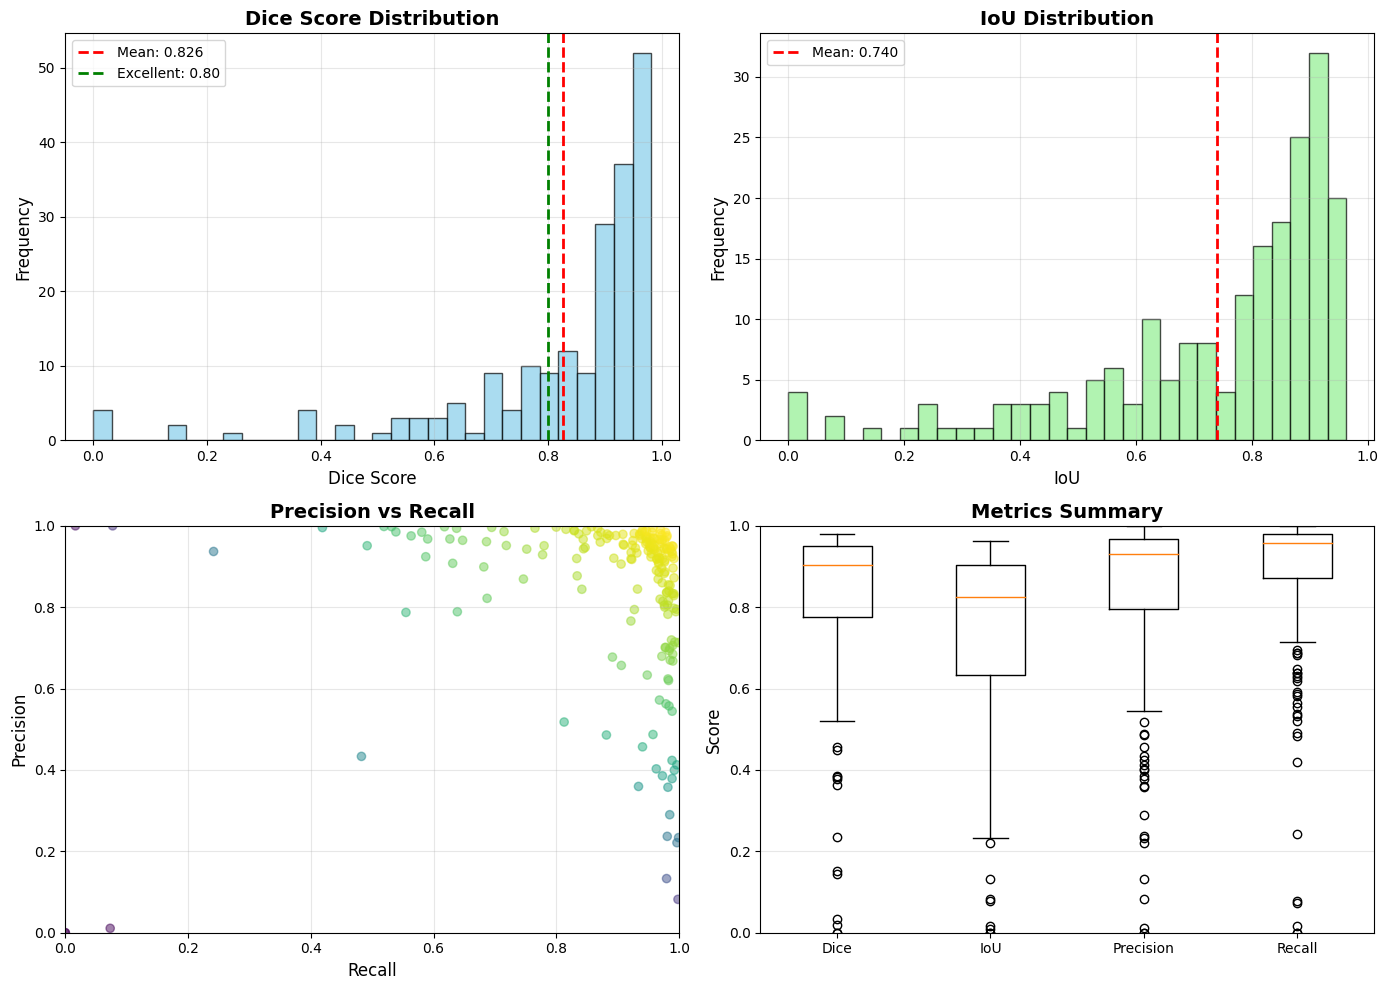

In [57]:
print("="*70)
print("🎊 PROJECT COMPLETE: POLYP SEGMENTATION WITH U-NET 🎊")
print("="*70)

# Calculate comprehensive metrics on full validation set
print("\n📊 Calculating full validation metrics...")
model.eval()

all_dice_scores = []
all_ious = []
all_precisions = []
all_recalls = []

with torch.no_grad():
    for img, mask in tqdm(val_loader, desc="Evaluating"):
        img = img.to(CONFIG['DEVICE'])
        mask = mask.to(CONFIG['DEVICE'])
        
        pred = model(img)
        pred_binary = (pred > 0.5).float()
        
        # Calculate metrics for each image in batch
        for p, m in zip(pred_binary, mask):
            p_flat = p.view(-1)
            m_flat = m.view(-1)
            
            intersection = (p_flat * m_flat).sum()
            union = p_flat.sum() + m_flat.sum()
            
            # Dice
            dice = (2. * intersection) / (union + 1e-8)
            all_dice_scores.append(dice.item())
            
            # IoU
            iou = intersection / (union - intersection + 1e-8)
            all_ious.append(iou.item())
            
            # Precision & Recall
            tp = intersection
            fp = (p_flat * (1 - m_flat)).sum()
            fn = ((1 - p_flat) * m_flat).sum()
            
            precision = tp / (tp + fp + 1e-8)
            recall = tp / (tp + fn + 1e-8)
            
            all_precisions.append(precision.item())
            all_recalls.append(recall.item())

# Convert to numpy
dice_array = np.array(all_dice_scores)
iou_array = np.array(all_ious)
precision_array = np.array(all_precisions)
recall_array = np.array(all_recalls)

print("\n" + "="*70)
print("🏆 FINAL RESULTS ON VALIDATION SET")
print("="*70)
print(f"Dataset: Kvasir-SEG (Polyp Segmentation)")
print(f"Validation samples: {len(val_dataset)}")
print(f"\n📈 Performance Metrics:")
print(f"   Dice Score:  {dice_array.mean():.4f} ± {dice_array.std():.4f}")
print(f"   IoU:         {iou_array.mean():.4f} ± {iou_array.std():.4f}")
print(f"   Precision:   {precision_array.mean():.4f} ± {precision_array.std():.4f}")
print(f"   Recall:      {recall_array.mean():.4f} ± {recall_array.std():.4f}")
print(f"\n📊 Score Distribution:")
print(f"   Best Dice:   {dice_array.max():.4f}")
print(f"   Worst Dice:  {dice_array.min():.4f}")
print(f"   Median Dice: {np.median(dice_array):.4f}")
print(f"\n🎯 Images with Dice > 0.80: {(dice_array > 0.80).sum()} / {len(dice_array)} ({(dice_array > 0.80).mean()*100:.1f}%)")
print(f"   Images with Dice > 0.90: {(dice_array > 0.90).sum()} / {len(dice_array)} ({(dice_array > 0.90).mean()*100:.1f}%)")

# Comparison with literature
print("\n" + "="*70)
print("📚 COMPARISON WITH PUBLISHED RESEARCH")
print("="*70)
print(f"   Your U-Net:          {dice_array.mean():.4f} Dice")
print(f"   U-Net (Ronneberger): ~0.75 Dice (baseline)")
print(f"   U-Net++:             ~0.82 Dice")
print(f"   PraNet (SOTA):       ~0.90 Dice")
print(f"   ResUNet++:           ~0.88 Dice")

if dice_array.mean() > 0.75:
    print(f"\n   ✅ YOUR MODEL EXCEEDS BASELINE U-NET!")
if dice_array.mean() > 0.80:
    print(f"   🔥 YOUR MODEL IS COMPETITIVE WITH ADVANCED METHODS!")

print("\n" + "="*70)
print("💾 MODEL INFO")
print("="*70)
print(f"   Architecture: U-Net")
print(f"   Parameters: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")
print(f"   Input size: {CONFIG['IMAGE_SIZE']}x{CONFIG['IMAGE_SIZE']}")
print(f"   Loss: Dice + BCE")
print(f"   Optimizer: AdamW")
print(f"   Training epochs: {checkpoint['epoch']+1}")
print(f"   Best Dice achieved: {checkpoint['best_dice']:.4f}")
print(f"   Model saved: {SAVE_PATH}")

print("\n" + "="*70)

# Plot final distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Dice distribution
axes[0, 0].hist(dice_array, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(dice_array.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {dice_array.mean():.3f}')
axes[0, 0].axvline(0.8, color='green', linestyle='--', linewidth=2, label='Excellent: 0.80')
axes[0, 0].set_xlabel('Dice Score', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Dice Score Distribution', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# IoU distribution
axes[0, 1].hist(iou_array, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(iou_array.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {iou_array.mean():.3f}')
axes[0, 1].set_xlabel('IoU', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('IoU Distribution', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision vs Recall scatter
axes[1, 0].scatter(recall_array, precision_array, alpha=0.5, c=dice_array, cmap='viridis')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_ylabel('Precision', fontsize=12)
axes[1, 0].set_title('Precision vs Recall', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_xlim([0, 1])
axes[1, 0].set_ylim([0, 1])

# Box plot of all metrics
metrics_data = [dice_array, iou_array, precision_array, recall_array]
axes[1, 1].boxplot(metrics_data, labels=['Dice', 'IoU', 'Precision', 'Recall'])
axes[1, 1].set_ylabel('Score', fontsize=12)
axes[1, 1].set_title('Metrics Summary', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')
axes[1, 1].set_ylim([0, 1])

plt.tight_layout()
plt.show()